In [6]:
# ==============================================================================
# SCRIPT DIDÁCTICO: ANÁLISIS COMPARATIVO ESPACIAL Y TEMPORAL EN HIDROLOGÍA
# Objetivo: Analizar dos cuencas simultáneamente, generar balances y boxplots.
# Nivel: Intermedio / Avanzado.
# ==============================================================================
# Referencias Bibliográficas:
# 1. CHIRPS (Precipitación): Funk, C., et al. (2015). Scientific Data.
# 2. MODIS (ET): Mu, Q., et al. (2011). Remote Sensing of Environment.
# 3. GLDAS (Nieve/Humedad): Rodell, M., et al. (2004). BAMS.
# 4. ERA5-Land (Temperatura): Muñoz-Sabater, J., et al. (2021). ESSD.
# ==============================================================================

import ee
from google.colab import drive
import geopandas as gpd
import geemap
import pandas as pd
import numpy as np
import time
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ------------------------------------------------------------------------------
# PANEL DE CONTROL CENTRAL
# ------------------------------------------------------------------------------

# A. Parámetros de las Cuencas (Análisis Simultáneo)
CUENCAS_OBJETIVO = ['054', '095'] # Añada o modifique los códigos aquí
COLUMNA_CUENCA = 'COD_CUEN'

# B. Parámetros Temporales
ANIO_INICIO = 2003
ANIO_FIN = 2025

# C. Configuración Dinámica de Variables Adicionales (ERA5-Land y GLDAS)
CONFIG_VARS_EXTRAS = [
    {
        'activo': True,
        'fuente': 'GLDAS',
        'banda_gee': 'SWE_tavg',
        'nombre_columna': 'SWE_Nieve',
        'reduccion_mensual_ee': 'mean',
        'reduccion_anual_pd': 'mean',
        'multiplicar_segundos_mes': False,
        'escala_m': 27830,
        'factor': 1.0,
        'offset': 0.0,
        'cor_grafico': '#2ca02c',
        'unidad_grafico': 'Nieve (mm)'
    },
    {
        'activo': True,
        'fuente': 'ERA5',
        'banda_gee': 'temperature_2m',
        'nombre_columna': 'Temp_C',
        'reduccion_mensual_ee': 'mean',
        'reduccion_anual_pd': 'mean',
        'multiplicar_segundos_mes': False,
        'escala_m': 11132,
        'factor': 1.0,
        'offset': -273.15,
        'cor_grafico': '#984ea3',
        'unidad_grafico': 'Celsius (°C)'
    }
]

# D. Optimización de Mapas
EXPORTAR_MULTIBANDA = False

# ------------------------------------------------------------------------------
# Autenticación
try:
    ee.Authenticate()
    ee.Initialize(project='lucasvituri') # Crear y cambiar el proyecto
    print("Earth Engine inicializado con éxito.")
except Exception as e:
    print(f"Error de inicialización: {e}")

drive.mount('/content/drive')

Earth Engine inicializado con éxito.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Descomprimiendo y cargando el Shapefile...
Se filtraron 4 polígonos para las cuencas: ['054', '095'].
Generando panel de mapas espaciales alineados y con escala...


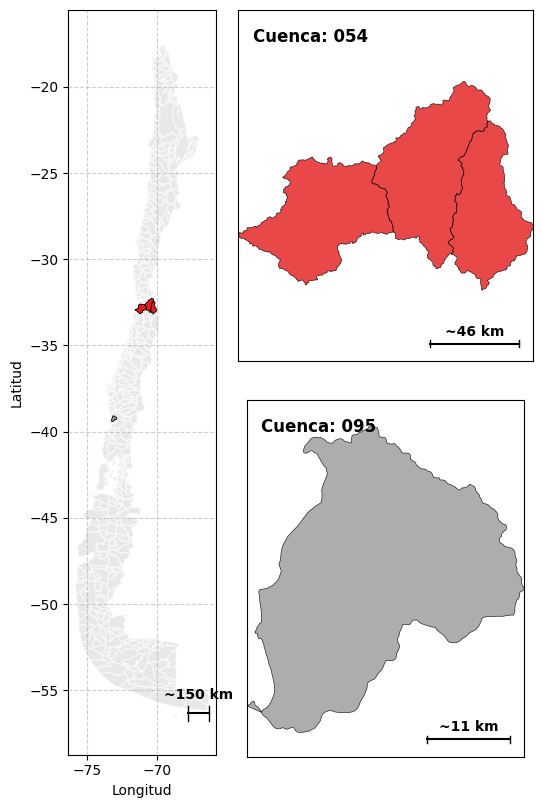

In [7]:
# ------------------------------------------------------------------------------
# 2. PROCESAMIENTO ESPACIAL Y MAPAS ESTÁTICOS
# ------------------------------------------------------------------------------
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import geopandas as gpd
import zipfile
import os
import numpy as np

print("\nDescomprimiendo y cargando el Shapefile...")

# Datos disponible en: https://dga.mop.gob.cl/mapoteca-digital/
# Bajar crear una carpeta y cambiar la ruta y subir el archivo .zip
ruta_zip = '/content/drive/MyDrive/GEOHIDRO_T4/SubCuencas.zip'
carpeta_extraccion = '/content/temp_shapefile'

if not os.path.exists(carpeta_extraccion):
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(carpeta_extraccion)

ruta_shp_extraido = None
for root, dirs, files in os.walk(carpeta_extraccion):
    for file in files:
        if file.endswith('.shp'):
            ruta_shp_extraido = os.path.join(root, file)
            break

if ruta_shp_extraido is None:
    raise FileNotFoundError("¡No se encontró ningún archivo .shp dentro del ZIP!")

gdf = gpd.read_file(ruta_shp_extraido)

# Filtro Continental (Limpieza de islas oceánicas)
LON_MINIMA_CONTINENTAL = -76.0
gdf_continental = gdf.cx[LON_MINIMA_CONTINENTAL: , :]

gdf_cuencas = gdf_continental[gdf_continental[COLUMNA_CUENCA].isin(CUENCAS_OBJETIVO)]

if gdf_cuencas.empty:
    print(f"¡ATENCIÓN! No se encontraron geometrías para las cuencas {CUENCAS_OBJETIVO}.")
else:
    print(f"Se filtraron {len(gdf_cuencas)} polígonos para las cuencas: {CUENCAS_OBJETIVO}.")


# ==============================================================================
# FUNCIÓN DE CARTOGRAFÍA: BARRA DE ESCALA NATIVA
# ==============================================================================
def agregar_escala(ax, longitud_grados, etiqueta, offset_y_pct=0.05, offset_x_pct=0.05):
    """
    Dibuja una barra de escala minimalista en la esquina inferior derecha.
    Nota: En grados geográficos, 0.1° equivale a ~10 km (dependiendo de la latitud).
    """
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Calcular posición (esquina inferior derecha)
    x_start = xmax - (xmax - xmin) * offset_x_pct - longitud_grados
    x_end = x_start + longitud_grados
    y_pos = ymin + (ymax - ymin) * offset_y_pct

    # Dibujar línea principal de la escala
    ax.plot([x_start, x_end], [y_pos, y_pos], color='black', linewidth=1.5)
    # Dibujar topes verticales (serifas)
    ax.plot([x_start, x_start], [y_pos - (ymax-ymin)*0.01, y_pos + (ymax-ymin)*0.01], color='black', linewidth=1)
    ax.plot([x_end, x_end], [y_pos - (ymax-ymin)*0.01, y_pos + (ymax-ymin)*0.01], color='black', linewidth=1)

    # Agregar texto encima de la línea
    ax.text(x_start + (longitud_grados/2), y_pos + (ymax-ymin)*0.015, etiqueta,
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


# ==============================================================================
# PARÁMETROS DE CARTOGRAFÍA FINA (Diseño Simétrico y Compacto)
# ==============================================================================
NIVEL_DE_ZOOM = 0
ESPACIADO_HORIZONTAL = 0.1
ESPACIADO_VERTICAL = 0.1
# ==============================================================================

print("Generando panel de mapas espaciales alineados y con escala...")

num_cuencas = len(CUENCAS_OBJETIVO)
fig = plt.figure(figsize=(5, 10))

gs = gridspec.GridSpec(
    num_cuencas, 2,
    width_ratios=[1.0, 2],
    wspace=ESPACIADO_HORIZONTAL,
    hspace=ESPACIADO_VERTICAL
)

# --- 1. MAPA PRINCIPAL (Izquierda) ---
ax_main = fig.add_subplot(gs[:, 0])
gdf_continental.plot(ax=ax_main, color='lightgrey', edgecolor='white', alpha=0.5)
gdf_cuencas.plot(ax=ax_main, column=COLUMNA_CUENCA, cmap='Set1', edgecolor='black', linewidth=0.5)

ax_main.set_xlabel("Longitud")
ax_main.set_ylabel("Latitud")
ax_main.grid(True, linestyle='--', alpha=0.6)

# Agregar escala al mapa regional (Aprox 1.0° ~ 100 km)
agregar_escala(ax_main, longitud_grados=1.5, etiqueta="~150 km")

colores = plt.cm.Set1(np.linspace(0, 1, max(num_cuencas, 2)))

# --- 2. MAPAS DE ZOOM (Derecha - Recuadros Simétricos) ---
for i, cuenca_id in enumerate(CUENCAS_OBJETIVO):
    ax_zoom = fig.add_subplot(gs[i, 1])
    gdf_individual = gdf_cuencas[gdf_cuencas[COLUMNA_CUENCA] == cuenca_id]

    if not gdf_individual.empty:
        gdf_individual.plot(ax=ax_zoom, color=colores[i], edgecolor='black', linewidth=0.5, alpha=0.8)

        # Bounding Box Cuadrado Perfecto
        minx, miny, maxx, maxy = gdf_individual.total_bounds
        centro_x = (maxx + minx) / 2
        centro_y = (maxy + miny) / 2

        dimension_max = max(maxx - minx, maxy - miny)
        margen = dimension_max * NIVEL_DE_ZOOM
        radio_final = (dimension_max / 2) + margen

        ax_zoom.set_xlim(centro_x - radio_final, centro_x + radio_final)
        ax_zoom.set_ylim(centro_y - radio_final, centro_y + radio_final)

        ax_zoom.set_xticks([])
        ax_zoom.set_yticks([])

        # Título flotante
        ax_zoom.text(0.05, 0.95, f"Cuenca: {cuenca_id}", transform=ax_zoom.transAxes,
                     fontsize=12, fontweight='bold', verticalalignment='top')

        # Agregar escala de detalle (Aprox 0.1° ~ 10 km, ajustable según la cuenca)
        # Se calcula el 20% del ancho del recuadro para que la escala sea siempre proporcional
        ancho_cuadro = (centro_x + radio_final) - (centro_x - radio_final)
        escala_grados = ancho_cuadro * 0.3
        # Redondeo simple para la etiqueta didáctica (1 grado latitudinal = ~111km)
        km_aprox = int(escala_grados * 100)
        agregar_escala(ax_zoom, longitud_grados=escala_grados, etiqueta=f"~{km_aprox} km")

# Ajuste global para recortar bordes blancos sobrantes
plt.subplots_adjust(top=0.85, bottom=0.10, left=0.05, right=0.98)

plt.show()
# ==============================================================================

In [8]:
# ------------------------------------------------------------------------------
# 3. EXTRACCIÓN DE LA SERIE TEMPORAL (ITERACIÓN POR CUENCA)
# ------------------------------------------------------------------------------
print(f"\nIniciando extracción mensual ({ANIO_INICIO}-{ANIO_FIN}) para {len(CUENCAS_OBJETIVO)} cuencas...")

anios = range(ANIO_INICIO, ANIO_FIN + 1)
meses = range(1, 13)
lista_features_global = []

col_chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
col_modis = ee.ImageCollection("MODIS/061/MOD16A2GF")
col_gldas = ee.ImageCollection("NASA/GLDAS/V022/CLSM/G025/DA1D")
col_era5 = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")

vars_activas = [v for v in CONFIG_VARS_EXTRAS if v['activo']]

# Diccionario para almacenar las geometrías de GEE para exportación posterior
geometrias_ee = {}

for cuenca_id in CUENCAS_OBJETIVO:
    print(f"-> Procesando cuenca: {cuenca_id}")
    gdf_individual = gdf_cuencas[gdf_cuencas[COLUMNA_CUENCA] == cuenca_id]
    aoi = geemap.geopandas_to_ee(gdf_individual)
    geom_aoi = aoi.geometry()
    geometrias_ee[cuenca_id] = geom_aoi # Guardado para el Módulo 5

    for anio in anios:
        for mes in meses:
            start_date = ee.Date.fromYMD(anio, mes, 1)
            end_date = start_date.advance(1, 'month')
            segundos_mes = end_date.difference(start_date, 'second')

            props_feat = {
                'Cuenca': cuenca_id, # Variable clave para separar en Pandas
                'Fecha': f"{anio}-{mes:02d}",
                'Anio': anio,
                'Mes': mes
            }

            chirps_mes = col_chirps.filterDate(start_date, end_date)
            props_feat['P_mm'] = ee.Algorithms.If(
                chirps_mes.size().gt(0),
                chirps_mes.sum().reduceRegion(reducer=ee.Reducer.mean(), geometry=geom_aoi, scale=5566, maxPixels=1e9).get('precipitation'),
                ee.Number(-9999)
            )

            tc_mes = col_modis.filterDate(start_date, end_date)
            props_feat['ET_mm'] = ee.Algorithms.If(
                tc_mes.size().gt(0),
                tc_mes.select('ET').sum().multiply(0.1).reduceRegion(reducer=ee.Reducer.mean(), geometry=geom_aoi, scale=500, maxPixels=1e9).get('ET'),
                ee.Number(-9999)
            )

            for config in vars_activas:
                fuente_col = col_era5 if config['fuente'] == 'ERA5' else col_gldas
                coleccion_filtrada = fuente_col.filterDate(start_date, end_date)
                img_mensual = coleccion_filtrada.select(config['banda_gee']).mean()

                if config.get('multiplicar_segundos_mes', False):
                    img_mensual = img_mensual.multiply(segundos_mes)

                img_mensual = img_mensual.multiply(config['factor']).add(config['offset'])

                props_feat[config['nombre_columna']] = ee.Algorithms.If(
                    coleccion_filtrada.size().gt(0),
                    img_mensual.reduceRegion(reducer=ee.Reducer.mean(), geometry=geom_aoi, scale=config['escala_m'], maxPixels=1e9).get(config['banda_gee']),
                    ee.Number(-9999)
                )

            lista_features_global.append(ee.Feature(None, props_feat))

# Descarga y ensamblaje del DataFrame unificado
fc_temporal = ee.FeatureCollection(lista_features_global)
datos_descargados = fc_temporal.getInfo()

df_serie = pd.DataFrame([f['properties'] for f in datos_descargados['features']])

cols_num = ['P_mm', 'ET_mm'] + [v['nombre_columna'] for v in vars_activas]
for col in cols_num:
    df_serie[col] = pd.to_numeric(df_serie[col], errors='coerce')
    df_serie[col] = df_serie[col].replace(-9999, np.nan).round(2)

df_serie['Balance_mm'] = df_serie['P_mm'] - df_serie['ET_mm']

ruta_csv = f'/content/drive/MyDrive/GEOHIDRO_T4/Serie_Temporal_Comparativa.csv'
os.makedirs(os.path.dirname(ruta_csv), exist_ok=True)
df_serie.to_csv(ruta_csv, index=False)
print(f"¡Extracción completada! CSV guardado en: {ruta_csv}")


Iniciando extracción mensual (2003-2025) para 2 cuencas...
-> Procesando cuenca: 054
-> Procesando cuenca: 095
¡Extracción completada! CSV guardado en: /content/drive/MyDrive/GEOHIDRO_T4/Serie_Temporal_Comparativa.csv


In [9]:
# ------------------------------------------------------------------------------
# 4. ANÁLISIS ESTADÍSTICO
# ------------------------------------------------------------------------------
print("\nRealizando análisis estadístico anual por cuenca...")

agg_dict_pd = {
    'P_mm': 'sum',
    'ET_mm': 'sum',
    'Balance_mm': 'sum'
}

for config in vars_activas:
    agg_dict_pd[config['nombre_columna']] = config['reduccion_anual_pd']

# Agrupamiento doble: por Cuenca y por Año
df_anual = df_serie.groupby(['Cuenca', 'Anio']).agg(agg_dict_pd).reset_index()
df_anual_cleaned = df_anual.dropna(subset=['P_mm', 'ET_mm'])

for cuenca_id in CUENCAS_OBJETIVO:
    df_c = df_anual_cleaned[df_anual_cleaned['Cuenca'] == cuenca_id]
    if not df_c.empty:
        anio_seco = int(df_c.loc[df_c['P_mm'].idxmin(), 'Anio'])
        anio_humedo = int(df_c.loc[df_c['P_mm'].idxmax(), 'Anio'])
        print(f"\n--- Resumen Cuenca {cuenca_id} ---")
        print(f"Año más SECO: {anio_seco} (P: {df_c['P_mm'].min():.1f} mm)")
        print(f"Año más HÚMEDO: {anio_humedo} (P: {df_c['P_mm'].max():.1f} mm)")
        print(f"P media histórica: {df_c['P_mm'].mean():.1f} mm/año")
        print(f"ET media histórica: {df_c['ET_mm'].mean():.1f} mm/año")


Realizando análisis estadístico anual por cuenca...

--- Resumen Cuenca 054 ---
Año más SECO: 2021 (P: 212.1 mm)
Año más HÚMEDO: 2024 (P: 561.4 mm)
P media histórica: 363.4 mm/año
ET media histórica: 286.9 mm/año

--- Resumen Cuenca 095 ---
Año más SECO: 2021 (P: 1040.8 mm)
Año más HÚMEDO: 2005 (P: 2081.4 mm)
P media histórica: 1396.8 mm/año
ET media histórica: 860.2 mm/año


In [10]:
# ------------------------------------------------------------------------------
# 5. GENERACIÓN DE DATOS ESPACIALES
# ------------------------------------------------------------------------------
print("\nPreparando exportación de mapas raster (iterando por cuencas)...")

def exportar_mapa(imagen, nombre_archivo, geom_cuenca, scale=5566):
    # Homogeneización estricta de tipos de datos a Float32 para prevenir el Error Code 3
    # Esto unifica variables dinámicas (ERA5/GLDAS en Float64) con CHIRPS/MODIS (Float32)
    imagen_homogenea = imagen.toFloat()

    task = ee.batch.Export.image.toDrive(
        image=imagen_homogenea.clip(geom_cuenca),
        description=nombre_archivo,
        folder='GEOHIDRO_T4',
        scale=scale,
        region=geom_cuenca.bounds(),
        maxPixels=1e10
    )
    task.start()
    print(f"Tarea despachada: {nombre_archivo}")

num_anios = ANIO_FIN - ANIO_INICIO + 1
rango_ini, rango_fin = f'{ANIO_INICIO}-01-01', f'{ANIO_FIN}-12-31'

p_mean = col_chirps.filterDate(rango_ini, rango_fin).sum().divide(num_anios)
et_mean = col_modis.filterDate(rango_ini, rango_fin).select('ET').sum().multiply(0.1).divide(num_anios)
img_balance = p_mean.subtract(et_mean)

# Construcción de la imagen compuesta (para todas las variables)
img_compuesta = p_mean.rename('P_Media') \
    .addBands(et_mean.rename('ET_Media')) \
    .addBands(img_balance.rename('Balance_Hidrico'))

for config in vars_activas:
    fuente_col = col_era5 if config['fuente'] == 'ERA5' else col_gldas
    img_anual = fuente_col.filterDate(rango_ini, rango_fin).select(config['banda_gee']).mean()
    if config.get('multiplicar_segundos_mes', False):
        img_anual = img_anual.multiply(31557600)
    img_anual = img_anual.multiply(config['factor']).add(config['offset'])
    img_compuesta = img_compuesta.addBands(img_anual.rename(config['nombre_columna']))

# Exportación iterativa por cuenca
for cuenca_id in CUENCAS_OBJETIVO:
    geom_actual = geometrias_ee[cuenca_id]

    if EXPORTAR_MULTIBANDA:
        nombre = f'Rasters_Multibanda_Cuenca_{cuenca_id}'
        exportar_mapa(img_compuesta, nombre, geom_actual, scale=5566)
    else:
        # Si se desactiva la exportación multibanda, exporta banda por banda de forma segura
        exportar_mapa(p_mean, f'P_Media_Cuenca_{cuenca_id}', geom_actual, 5566)
        exportar_mapa(img_balance, f'Balance_Cuenca_{cuenca_id}', geom_actual, 500)


Preparando exportación de mapas raster (iterando por cuencas)...
Tarea despachada: P_Media_Cuenca_054
Tarea despachada: Balance_Cuenca_054
Tarea despachada: P_Media_Cuenca_095
Tarea despachada: Balance_Cuenca_095



[Módulo 6] Trazando el panel temporal comparativo...


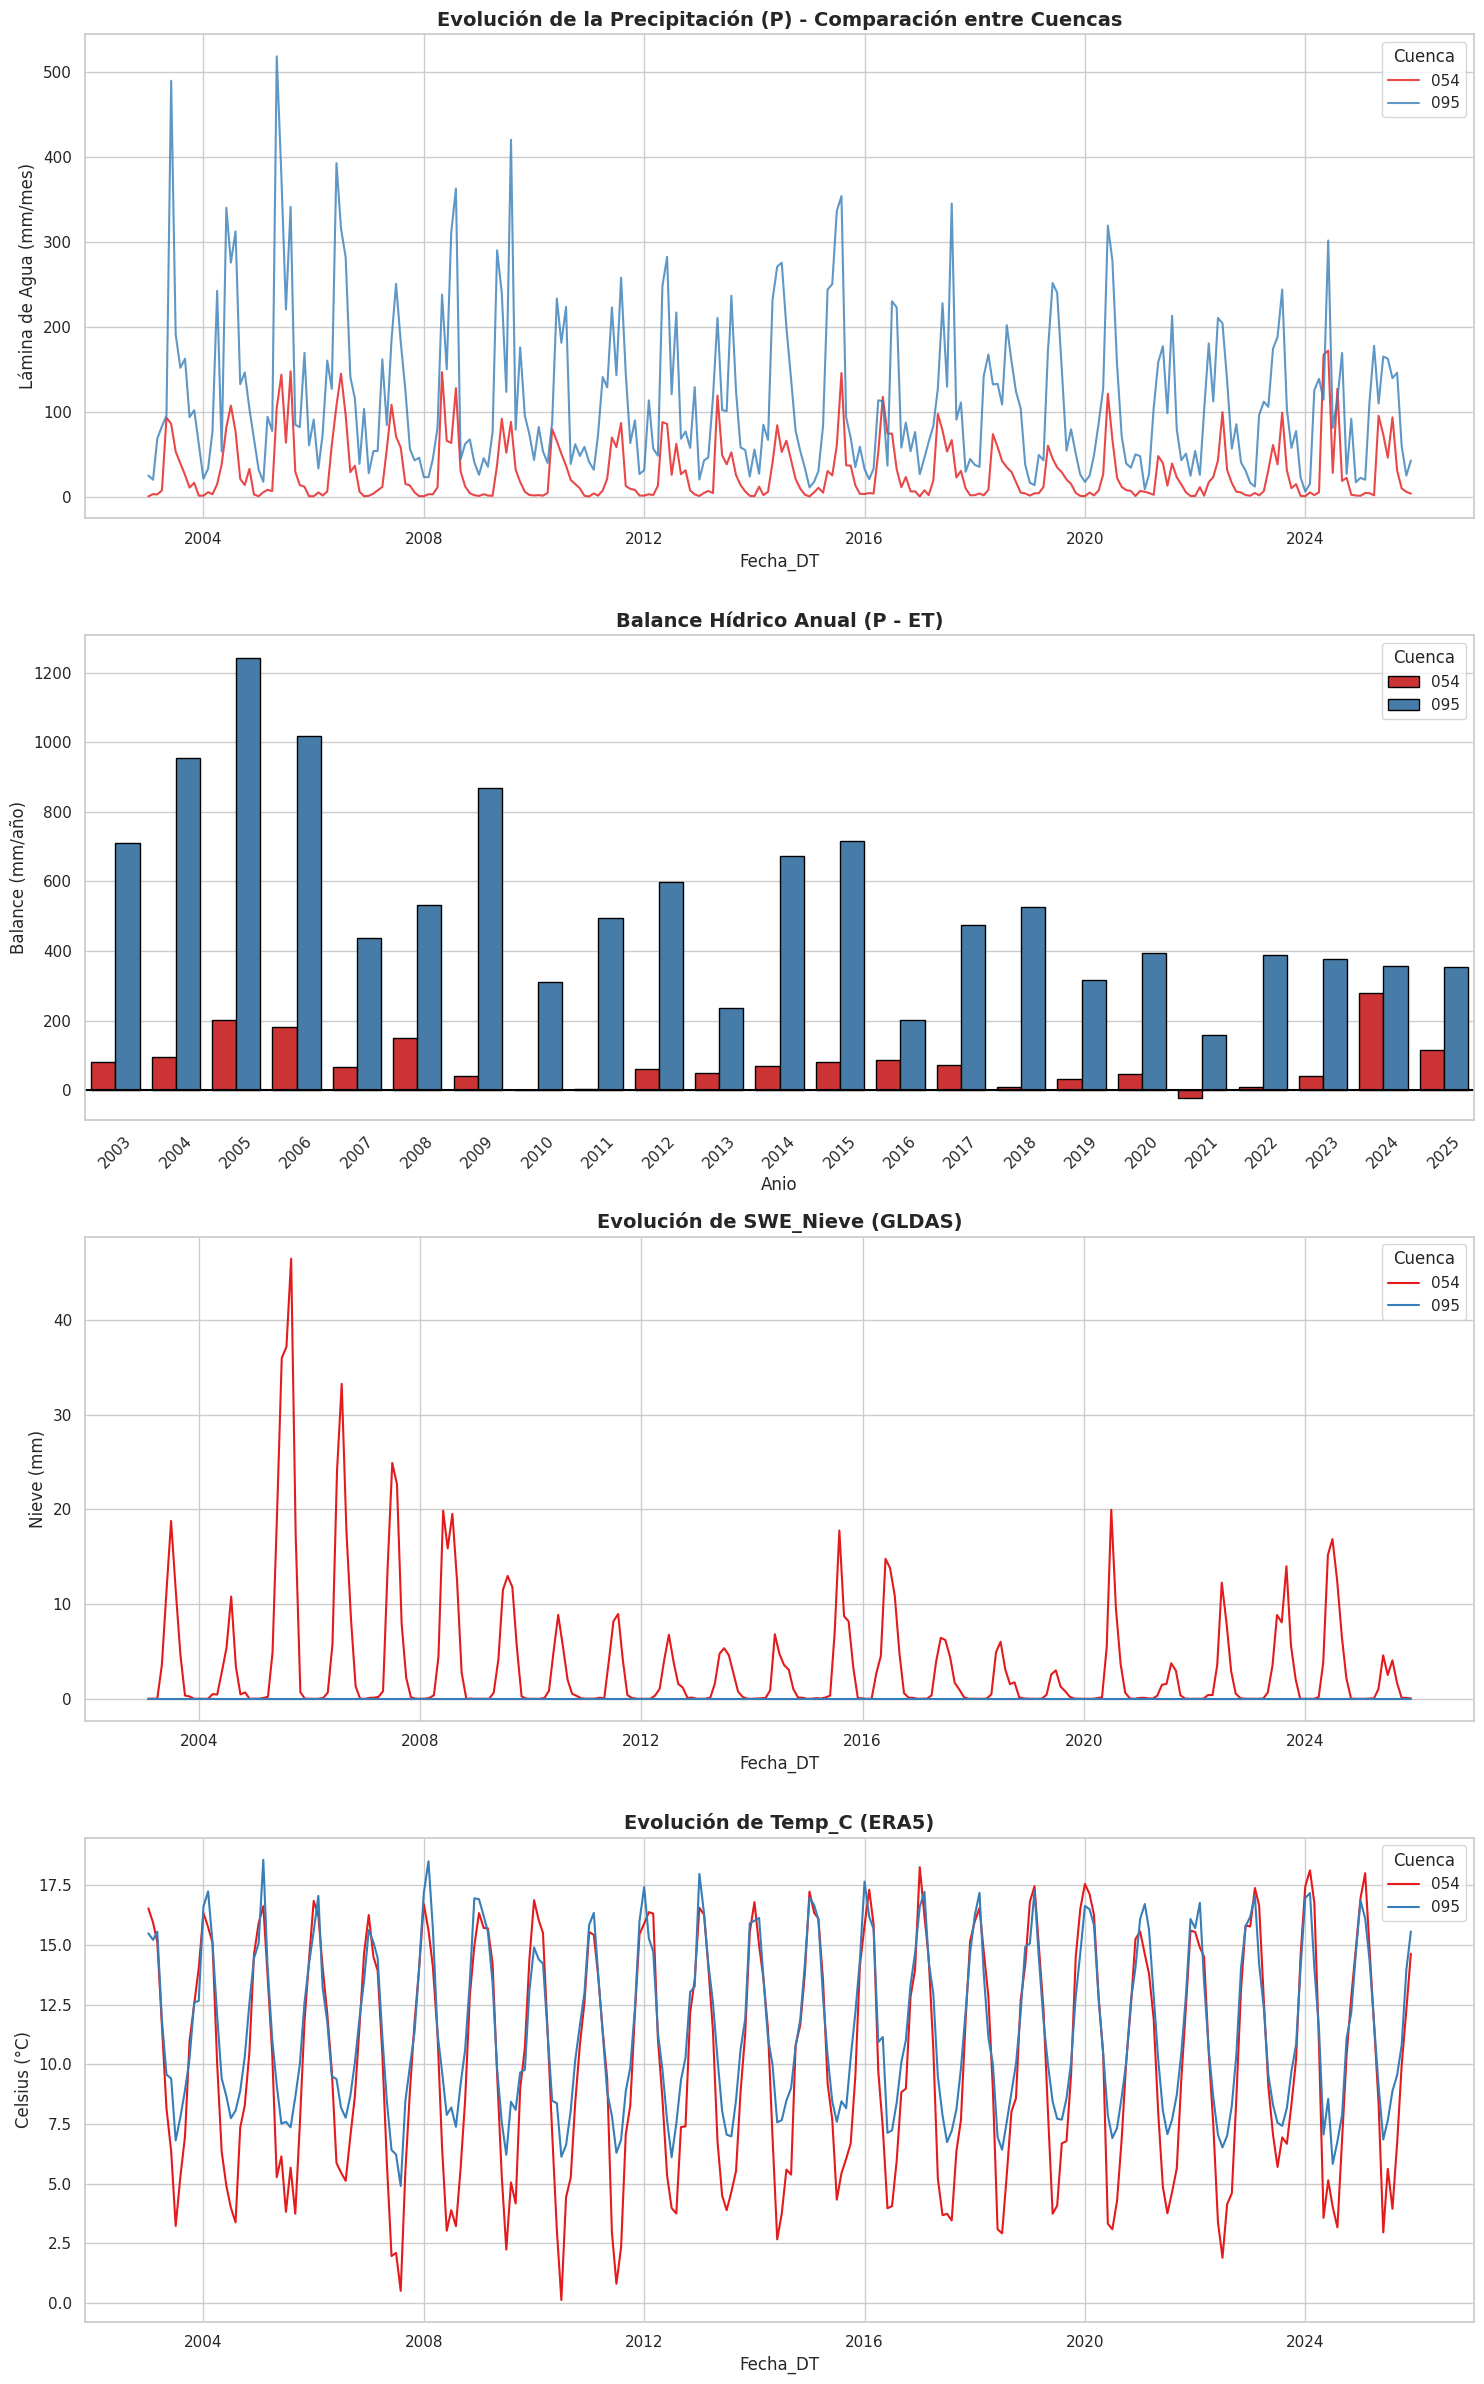

In [11]:
# ==============================================================================
# 6. VISUALIZACIÓN TEMPORAL (ANÁLISIS COMPARATIVO)
# ==============================================================================
print(f"\n[Módulo 6] Trazando el panel temporal comparativo...")
sns.set_theme(style="whitegrid")
df_serie['Fecha_DT'] = pd.to_datetime(df_serie['Fecha'])

num_plots = 2 + len(vars_activas)
fig, axes = plt.subplots(num_plots, 1, figsize=(15, 6 * num_plots))

colores_cuencas = sns.color_palette("Set1", len(CUENCAS_OBJETIVO))

# --- GRÁFICO 1: Dinámica de P ---
ax1 = axes[0]
sns.lineplot(data=df_serie, x='Fecha_DT', y='P_mm', hue='Cuenca', palette=colores_cuencas, ax=ax1, linewidth=1.5, alpha=0.8)
ax1.set_title('Evolución de la Precipitación (P) - Comparación entre Cuencas', fontsize=14, fontweight='bold')
ax1.set_ylabel('Lámina de Agua (mm/mes)')

# --- GRÁFICO 2: Balance Hídrico Anual ---
ax2 = axes[1]
sns.barplot(data=df_anual, x='Anio', y='Balance_mm', hue='Cuenca', palette=colores_cuencas, ax=ax2, edgecolor='black')
ax2.axhline(0, color='black', linewidth=1.5)
ax2.set_title('Balance Hídrico Anual (P - ET)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Balance (mm/año)')
ax2.tick_params(axis='x', rotation=45)

# --- GRÁFICOS 3 a N: Variables Dinámicas ---
plot_idx = 2
for config in vars_activas:
    ax = axes[plot_idx]
    sns.lineplot(data=df_serie, x='Fecha_DT', y=config['nombre_columna'], hue='Cuenca', palette=colores_cuencas, ax=ax, linewidth=1.5)
    ax.set_title(f"Evolución de {config['nombre_columna']} ({config['fuente']})", fontsize=14, fontweight='bold')
    ax.set_ylabel(config['unidad_grafico'])
    plot_idx += 1

plt.tight_layout()
ruta_grafico = '/content/drive/MyDrive/GEOHIDRO_T4/Panel_Temporal_Comparativo.png'
plt.savefig(ruta_grafico, dpi=300)
plt.show()


[Módulo 7] Trazando boxplots de estacionalidad mensual...


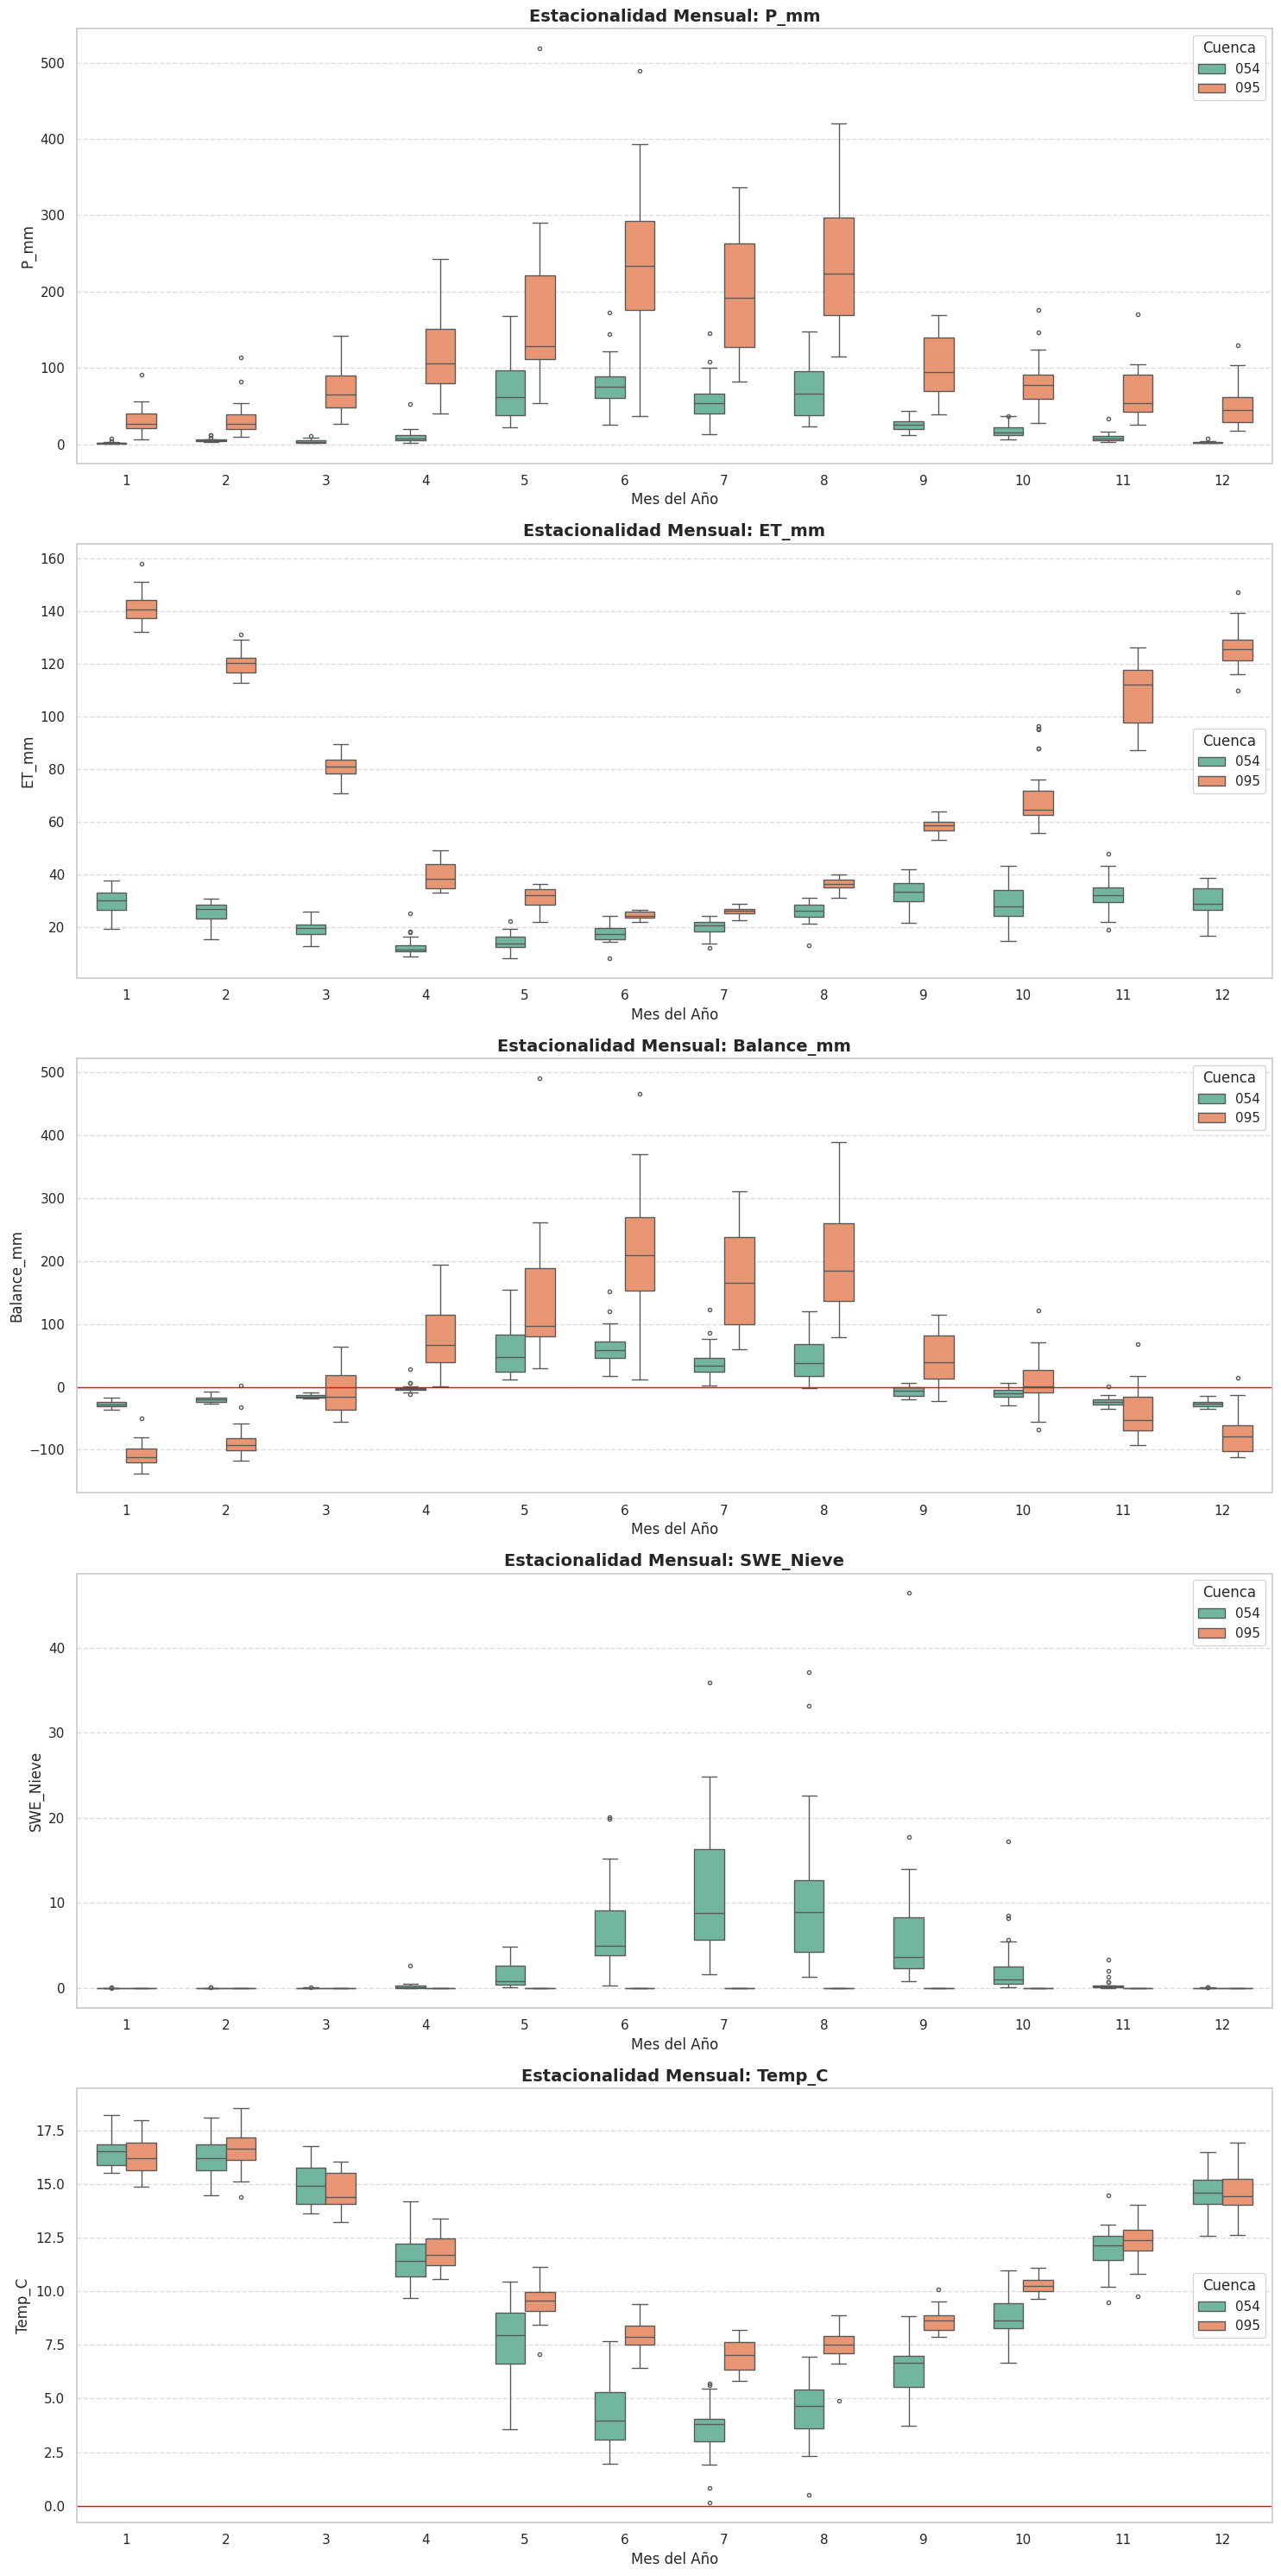

In [12]:
# ==============================================================================
# 7. VISUALIZACIÓN DE ESTACIONALIDAD (BOXPLOTS MENSUALES)
# ==============================================================================
print(f"\n[Módulo 7] Trazando boxplots de estacionalidad mensual...")

# Identificamos las variables numéricas a plotear (P, ET, Balance y las extras)
variables_boxplot = ['P_mm', 'ET_mm', 'Balance_mm'] + [v['nombre_columna'] for v in vars_activas]

fig, axes = plt.subplots(len(variables_boxplot), 1, figsize=(15, 6 * len(variables_boxplot)))

for i, var in enumerate(variables_boxplot):
    ax = axes[i]
    # Boxplot agrupado por Mes y separado por Cuenca
    sns.boxplot(data=df_serie, x='Mes', y=var, hue='Cuenca', palette="Set2", ax=ax, width=0.6, fliersize=3)

    ax.set_title(f'Estacionalidad Mensual: {var}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Mes del Año', fontsize=12)
    ax.set_ylabel(var, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Línea base en 0 para el balance hídrico
    if var == 'Balance_mm' or var == 'Temp_C':
        ax.axhline(0, color='red', linestyle='-', linewidth=1)

plt.tight_layout()
ruta_boxplot = '/content/drive/MyDrive/GEOHIDRO_T4/Panel_Boxplots_Estacionales.png'
plt.savefig(ruta_boxplot, dpi=300)
plt.show()